# Exploring soil modeling in soilice

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl

In [2]:
from soilice.src_soil import MakeDictFloat
from soilice.src_soil import MakeDictArray
from soilice.src_soil import GCEfun
from soilice.src_soil import thetaFun
from soilice.balanceChecks import soilBalanceCheck
from soilice.src_soil import run

In [3]:
from animate import animate
from IPython.display import HTML

from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec

In [4]:
# Soil model options:
opts={}
opts['massflag']=1.              # Solve correct equations (set to zero to remove Cdtheta/dt)
opts['gravity']=1.               # 0. for horizontal; 1. for vertical
opts['cryoflow']=0.              # 0. flow based on psie; 1. flow based on psif 
opts['withadv']=1.               # 0. turn off advection; 1. turn on advection
opts['conductionTop']=0.         # 0. no conduction on upper BC; 1. conduction based on TTop
opts['conductionBot']=1.         # 0. no conduction on lower BC; 1. conduction based on TBot
opts['simulateFlow']=True        # 0. no flow, constant total water content; 1. simulates flow
opts['simulateTransport']=True   # 0. no flow, constant total water content; 1. simulates heat transport
opts['freeDrainage']=1.          # 0. no flow lower BC, 1.0 free draining lowerBC
opts['groundHeatFlux']=1.        # 0. no specified ground heat flux; 1. use specified ground heat flux.

In [5]:
# Import soil parameters:
from soilice.pars_loam import pars

# Import constants:
from soilice.constants import const

# Convert parameter units into days:
pars['Ks']=pars['Ks']*86400
pars['kappa_org']=pars['kappa_org']*86400
pars['kappa_soil']=pars['kappa_soil']*86400
const['kappa_air']=const['kappa_air']*86400
const['kappa_ice']=const['kappa_ice']*86400
const['kappa_liq']=const['kappa_liq']*86400

In [6]:
# Space grid
zMax=2.
dz=0.02
z=np.arange(dz/2,zMax,dz)
nz=len(z)
dz=np.zeros(nz)+dz

# Time grid
t=np.arange(0,365*3+200,1) # days
nt=len(t)
dt=t[1]-t[0]

In [7]:
# # For a uniform simulation, just run this code unmodified. This is more efficient:
parsD=MakeDictFloat()
for k in pars: parsD[k]=pars[k]

In [8]:
# Run scenarios with different boundary/initial conditions
# Boundary conditions - mass and heat fluxes:
qI=np.zeros(nt)+0.0005
TInf=np.zeros(nt)
TTop=np.zeros(nt) #np.sin(t/365*2*np.pi)
TBot=np.zeros(nt)+1.
jTopBC=np.sin(t/365*2*np.pi)*2e5 #np.zeros(nt)  # Specified ground heat flux, if used.

psi0=np.zeros(nz)-2 # z-zMax 
T0=np.linspace(1,1,nz)

psie1,T1,thetaL1,thetaI1,qT1,qB1,jT1,jB=run(dt,t,dz,nz,T0,psi0,qI,TTop,TBot,TInf,jTopBC,parsD,const,opts,rtol=1e-8)

psif1=T1*const['lambda_f']/(const['g']*const['T0'])
psif1[psif1>0]=0.
psif1=np.minimum(psie1,psif1)
h1=np.array([psie1[i,:]-z for i in range(nt)])

ode, with jac runtime = 10.88 seconds


[Text(0.0, 0, ''),
 Text(50.0, 0, ''),
 Text(100.0, 0, ''),
 Text(150.0, 0, ''),
 Text(200.0, 0, ''),
 Text(250.0, 0, ''),
 Text(300.0, 0, ''),
 Text(350.0, 0, ''),
 Text(400.0, 0, '')]

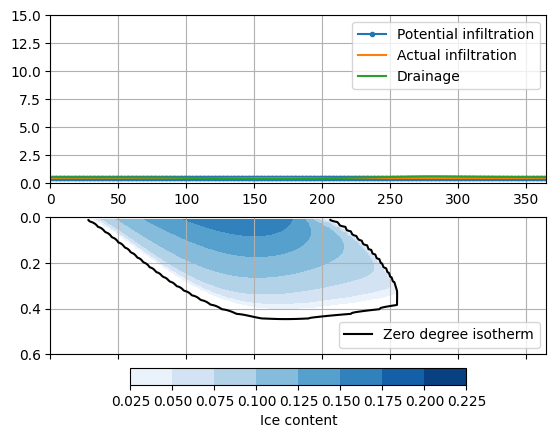

In [9]:
start=-365
pl.subplot(2,1,1)
pl.plot(t[start:]-t[start],qI[start:]*1000,'.-',label='Potential infiltration') 
pl.plot(t[start:]-t[start],qT1[start:]/dt*1000,label='Actual infiltration')
pl.plot(t[start:]-t[start],qB1[start:]/dt*1000,label='Drainage')
pl.legend()
pl.grid()
pl.ylim(0,15)
pl.xlim(0,365)
pl.subplot(2,1,2)
pl.plot(np.nan,np.nan,'-k',label='Zero degree isotherm')
cf=pl.contourf(t[start:]-t[start],z,thetaI1[start:,:].T,np.arange(0.025,0.25,0.025),cmap='Blues')
pl.contour(t[start:]-t[start],z,T1[start:,:].T,[0],colors='k')
pl.legend(loc=4)
cbar = pl.colorbar(cf,orientation='horizontal', fraction=0.1, pad=0.08)
cbar.set_label('Ice content')
pl.grid()
pl.ylim(0.6,0)
pl.xlim(0,365)
pl.gca().set_xticklabels('')

In [10]:
# Run scenarios with different boundary/initial conditions
# Boundary conditions - mass and heat fluxes:
qI=np.zeros(nt)+0.0005
qI[(t%365>30)&(t%365<60)]=0.01
TInf=np.zeros(nt)+5
TInf[(t%365>30)&(t%365<60)]=0.
# qI1=np.zeros(nt)
# TInf=np.zeros(nt)
TTop=np.zeros(nt) #np.sin(t/365*2*np.pi)
TBot=np.zeros(nt)+1.
jTopBC=np.sin(t/365*2*np.pi)*2e5 #np.zeros(nt)  # Specified ground heat flux, if used.

psi0=np.zeros(nz)-2 # z-zMax 
T0=np.linspace(1,1,nz)

In [11]:
# pl.subplot(3,1,1)
# pl.plot(t,jTopBC)
# pl.subplot(3,1,2)
# pl.plot(t,qI)
# pl.subplot(3,1,3)
# pl.plot(t,TInf)

In [12]:
psie1,T1,thetaL1,thetaI1,qT1,qB1,jT1,jB=run(dt,t,dz,nz,T0,psi0,qI,TTop,TBot,TInf,jTopBC,parsD,const,opts,rtol=1e-8)

psif1=T1*const['lambda_f']/(const['g']*const['T0'])
psif1[psif1>0]=0.
psif1=np.minimum(psie1,psif1)
h1=np.array([psie1[i,:]-z for i in range(nt)])

ode, with jac runtime = 7.49 seconds


[Text(0.0, 0, ''),
 Text(50.0, 0, ''),
 Text(100.0, 0, ''),
 Text(150.0, 0, ''),
 Text(200.0, 0, ''),
 Text(250.0, 0, ''),
 Text(300.0, 0, ''),
 Text(350.0, 0, ''),
 Text(400.0, 0, '')]

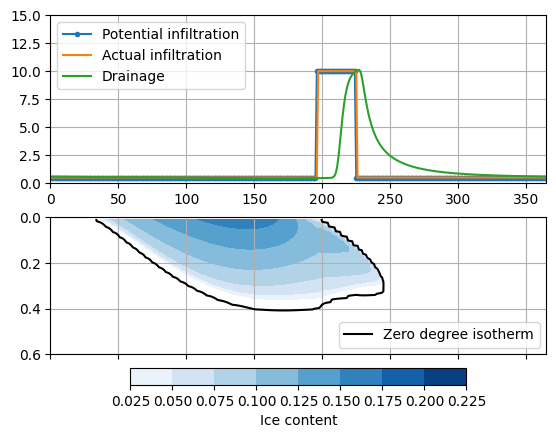

In [13]:
start=-365
pl.subplot(2,1,1)
pl.plot(t[start:]-t[start],qI[start:]*1000,'.-',label='Potential infiltration') 
pl.plot(t[start:]-t[start],qT1[start:]/dt*1000,label='Actual infiltration')
pl.plot(t[start:]-t[start],qB1[start:]/dt*1000,label='Drainage')
pl.legend()
pl.grid()
pl.ylim(0,15)
pl.xlim(0,365)
pl.subplot(2,1,2)
pl.plot(np.nan,np.nan,'-k',label='Zero degree isotherm')
cf=pl.contourf(t[start:]-t[start],z,thetaI1[start:,:].T,np.arange(0.025,0.25,0.025),cmap='Blues')
pl.contour(t[start:]-t[start],z,T1[start:,:].T,[0],colors='k')
pl.legend(loc=4)
cbar = pl.colorbar(cf,orientation='horizontal', fraction=0.1, pad=0.08)
cbar.set_label('Ice content')
pl.grid()
pl.ylim(0.6,0)
pl.xlim(0,365)
pl.gca().set_xticklabels('')

In [14]:
# Run scenarios with different boundary/initial conditions
# Boundary conditions - mass and heat fluxes:
qI=np.zeros(nt)+0.0005
qI[(t%365>0)&(t%365<30)]=0.01
TInf=np.zeros(nt)+5
TInf[(t%365>0)&(t%365<30)]=0.
# qI1=np.zeros(nt)
# TInf=np.zeros(nt)
TTop=np.zeros(nt) #np.sin(t/365*2*np.pi)
TBot=np.zeros(nt)+1.
jTopBC=np.sin(t/365*2*np.pi)*2e5 #np.zeros(nt)  # Specified ground heat flux, if used.

psi0=np.zeros(nz)-2 # z-zMax 
T0=np.linspace(1,1,nz)

In [15]:
psie1,T1,thetaL1,thetaI1,qT1,qB1,jT1,jB=run(dt,t,dz,nz,T0,psi0,qI,TTop,TBot,TInf,jTopBC,parsD,const,opts,rtol=1e-8)

psif1=T1*const['lambda_f']/(const['g']*const['T0'])
psif1[psif1>0]=0.
psif1=np.minimum(psie1,psif1)
h1=np.array([psie1[i,:]-z for i in range(nt)])

ode, with jac runtime = 7.82 seconds


[Text(0.0, 0, ''),
 Text(50.0, 0, ''),
 Text(100.0, 0, ''),
 Text(150.0, 0, ''),
 Text(200.0, 0, ''),
 Text(250.0, 0, ''),
 Text(300.0, 0, ''),
 Text(350.0, 0, ''),
 Text(400.0, 0, '')]

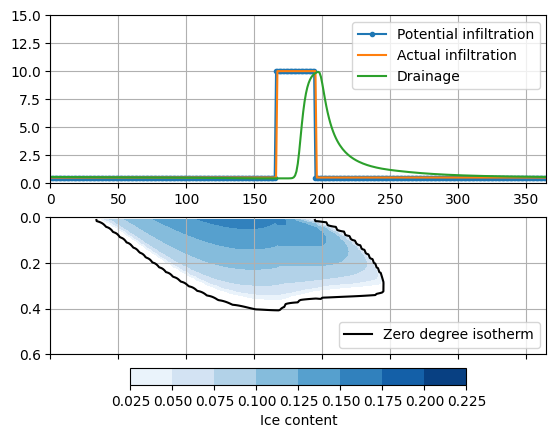

In [16]:
start=-365
pl.subplot(2,1,1)
pl.plot(t[start:]-t[start],qI[start:]*1000,'.-',label='Potential infiltration') 
pl.plot(t[start:]-t[start],qT1[start:]/dt*1000,label='Actual infiltration')
pl.plot(t[start:]-t[start],qB1[start:]/dt*1000,label='Drainage')
pl.legend()
pl.grid()
pl.ylim(0,15)
pl.xlim(0,365)
pl.subplot(2,1,2)
pl.plot(np.nan,np.nan,'-k',label='Zero degree isotherm')
cf=pl.contourf(t[start:]-t[start],z,thetaI1[start:,:].T,np.arange(0.025,0.25,0.025),cmap='Blues')
pl.contour(t[start:]-t[start],z,T1[start:,:].T,[0],colors='k')
pl.legend(loc=4)
cbar = pl.colorbar(cf,orientation='horizontal', fraction=0.1, pad=0.08)
cbar.set_label('Ice content')
pl.grid()
pl.ylim(0.6,0)
pl.xlim(0,365)
pl.gca().set_xticklabels('')